In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
try:
    df = pd.read_excel('data/storedata_total.xlsx')
    dict_df = pd.read_excel('data/storedata_total.xlsx')
    print("Files loaded successfully!")
except FileNotFoundError:
    print("Check your filename! Make sure it matches 'storedata_total.xlsx - data.csv'")

C:\Users\Testing\AppData\Roaming\Python\Python314\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Files loaded successfully!


C:\Users\Testing\AppData\Roaming\Python\Python314\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [23]:
print("Columns:", df.columns.tolist())
print(df.info())
print(df.isnull().sum())

Columns: ['custid', 'retained', 'created', 'firstorder', 'lastorder', 'esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq', 'paperless', 'refill', 'doorstep', 'favday', 'city']
<class 'pandas.DataFrame'>
RangeIndex: 30801 entries, 0 to 30800
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   custid      30781 non-null  object        
 1   retained    30801 non-null  int64         
 2   created     30781 non-null  datetime64[us]
 3   firstorder  30781 non-null  object        
 4   lastorder   30781 non-null  object        
 5   esent       30801 non-null  int64         
 6   eopenrate   30801 non-null  float64       
 7   eclickrate  30801 non-null  float64       
 8   avgorder    30801 non-null  float64       
 9   ordfreq     30801 non-null  float64       
 10  paperless   30801 non-null  int64         
 11  refill      30801 non-null  int64         
 12  doorstep    30801 non-null  int64         


In [24]:
date_cols = ['created', 'firstorder', 'lastorder']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [25]:
numeric_cols = ['esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df[numeric_cols] = df[numeric_cols].fillna(0)

In [26]:
df = df.dropna(subset=['retained'])

In [27]:
retention_count = df['retained'].value_counts()
retention_rate = (retention_count[1] / len(df)) * 100
churn_rate = 100 - retention_rate

print(f"\nRetention Rate: {retention_rate:.2f}%")
print(f"Churn Rate: {churn_rate:.2f}%")


Retention Rate: 79.45%
Churn Rate: 20.55%


In [28]:
profile_comparison = df.groupby('retained')[numeric_cols].mean()
print("\nProfile Comparison (Mean values):")
print(profile_comparison)


Profile Comparison (Mean values):
              esent  eopenrate  eclickrate   avgorder   ordfreq
retained                                                       
0          4.496919  21.207903    4.785196  61.550188  0.035523
1         34.252615  26.679051    5.900263  61.957675  0.038299


In [29]:
sub_cols = ['paperless', 'refill', 'doorstep']
sub_comparison = df.groupby('retained')[sub_cols].mean()
print("\nSubscription Comparison (Mean adoption rate):")
print(sub_comparison)


Subscription Comparison (Mean adoption rate):
          paperless    refill  doorstep
retained                               
0          0.480171  0.035393  0.013588
1          0.692710  0.110534  0.045440


In [30]:
df['engagement_score'] = (df['eopenrate'] / 100) + (df['eclickrate'] / 100) + (df['ordfreq'] * 10)
df['Segment'] = pd.qcut(df['engagement_score'], 3, labels=["Low Engagement", "Medium Engagement", "High Engagement"])

In [31]:
segment_churn = df.groupby('Segment')['retained'].mean().reset_index()
segment_churn['Churn_Likelihood'] = (1 - segment_churn['retained']) * 100

print("\nSegment Churn Likelihood:")
print(segment_churn)


Segment Churn Likelihood:
             Segment  retained  Churn_Likelihood
0     Low Engagement  0.731301         26.869887
1  Medium Engagement  0.846191         15.380869
2    High Engagement  0.806078         19.392228


In [34]:
plt.figure(figsize=(24, 18), dpi=100)
sns.set_style("whitegrid")

<Figure size 2400x1800 with 0 Axes>

Text(0.5, 1.0, 'Overall Customer Retention vs Churn')

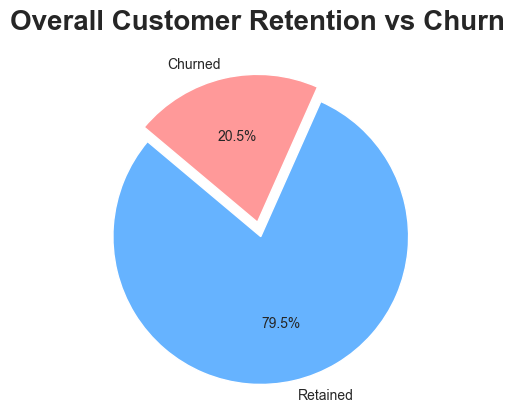

In [36]:
plt.subplot(1,1,1)
plt.pie([retention_rate, churn_rate], labels=['Retained', 'Churned'], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=140, explode=(0.1, 0))
plt.title('Overall Customer Retention vs Churn', fontsize=20, fontweight='bold')

C:\Users\Testing\AppData\Local\Temp\ipykernel_18408\2735099095.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='retained', y='ordfreq', palette='coolwarm')


Text(0, 0.5, 'Order Frequency')

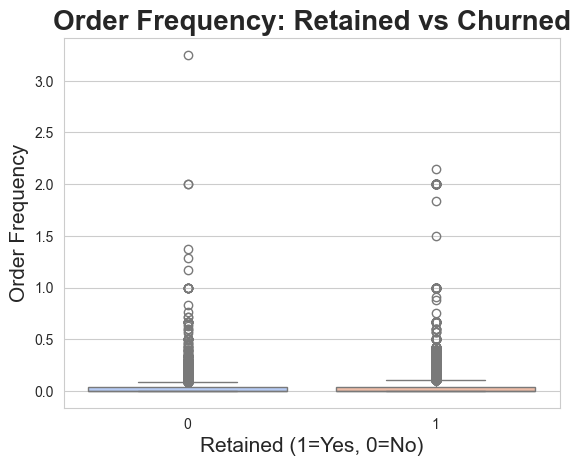

In [37]:
plt.subplot(1,1,1)
sns.boxplot(data=df, x='retained', y='ordfreq', palette='coolwarm')
plt.title('Order Frequency: Retained vs Churned', fontsize=20, fontweight='bold')
plt.xlabel('Retained (1=Yes, 0=No)', fontsize=15)
plt.ylabel('Order Frequency', fontsize=15)

C:\Users\Testing\AppData\Local\Temp\ipykernel_18408\2604734780.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_churn, x='Segment', y='Churn_Likelihood', palette='Reds_r')


Text(0, 0.5, 'Churn Probability (%)')

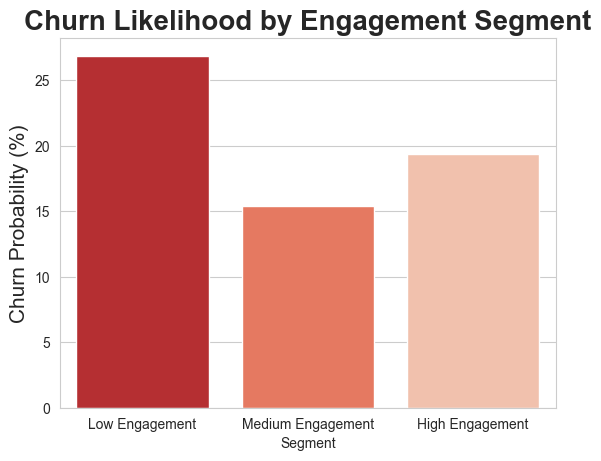

In [38]:
plt.subplot(1,1,1)
sns.barplot(data=segment_churn, x='Segment', y='Churn_Likelihood', palette='Reds_r')
plt.title('Churn Likelihood by Engagement Segment', fontsize=20, fontweight='bold')
plt.ylabel('Churn Probability (%)', fontsize=15)

C:\Users\Testing\AppData\Local\Temp\ipykernel_18408\2700767026.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['retained']==1], x='eopenrate', label='Retained', shade=True, color='blue')
C:\Users\Testing\AppData\Local\Temp\ipykernel_18408\2700767026.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['retained']==0], x='eopenrate', label='Churned', shade=True, color='red')


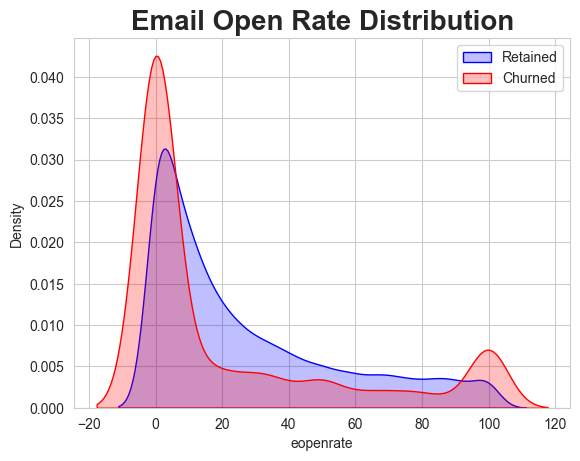

In [39]:
plt.subplot(1,1,1)
sns.kdeplot(data=df[df['retained']==1], x='eopenrate', label='Retained', shade=True, color='blue')
sns.kdeplot(data=df[df['retained']==0], x='eopenrate', label='Churned', shade=True, color='red')
plt.title('Email Open Rate Distribution', fontsize=20, fontweight='bold')
plt.legend()

In [40]:
plt.tight_layout(pad=6.0)
plt.savefig('retention_analysis_dashboard.png')
plt.show()

<Figure size 640x480 with 0 Axes>

In [41]:
df.to_csv('final_retention_data.csv', index=False)